# Predicting Financial Risk: Credit Card Default Analysis

From Raw Metadata to Predictive Insights

In the banking industry, predicting whether a client will default on their payment is a high-stakes challenge. A successful model doesn't just save money; it helps identify financial distress before it becomes a crisis.

This notebook takes a deep dive into the UCI Credit Card Default dataset, moving from meticulous data cleaning to building a Random Forest Classifier. My goal was to move beyond simple statistics and uncover the specific "red flags" that signal a high risk of default.

Project Roadmap:


1. Data Rectification: Fixing undocumented categorical values in Education and Marriage.
2. Exploratory Data Analysis: Visualizing the relationship between credit limits, payment history, and default.
3. Feature Engineering: Creating high-impact metrics like Utilization_Ratio and Late_Count.
4. Predictive Modeling: Training an ensemble model tuned for imbalanced data.
5. Interpretation: Using Feature Importance to explain the "why" behind the predictions.


There are 25 variables:

ID: ID of each client

LIMIT_BAL: Amount of given credit in NT dollars (includes individual and family/supplementary credit

SEX: Gender (1=male, 2=female)

EDUCATION: (1=graduate school, 2=university, 3=high school, 4=others, 5=unknown, 6=unknown)

MARRIAGE: Marital status (1=married, 2=single, 3=others)

AGE: Age in years

PAY_0: Repayment status in September, 2005 (-1=pay duly, 1=payment delay for one month, 2=payment delay for two 
months, … 8=payment delay for eight months, 9=payment delay for nine months and above)

PAY_2: Repayment status in August, 2005 (scale same as above)

PAY_3: Repayment status in July, 2005 (scale same as above)

PAY_4: Repayment status in June, 2005 (scale same as above)

PAY_5: Repayment status in May, 2005 (scale same as above)

PAY_6: Repayment status in April, 2005 (scale same as above)

BILL_AMT1: Amount of bill statement in September, 2005 (NT dollar)

BILL_AMT2: Amount of bill statement in August, 2005 (NT dollar)

BILL_AMT3: Amount of bill statement in July, 2005 (NT dollar)

BILL_AMT4: Amount of bill statement in June, 2005 (NT dollar)

BILL_AMT5: Amount of bill statement in May, 2005 (NT dollar)

BILL_AMT6: Amount of bill statement in April, 2005 (NT dollar)

PAY_AMT1: Amount of previous payment in September, 2005 (NT dollar)

PAY_AMT2: Amount of previous payment in August, 2005 (NT dollar)

PAY_AMT3: Amount of previous payment in July, 2005 (NT dollar)

PAY_AMT4: Amount of previous payment in June, 2005 (NT dollar)

PAY_AMT5: Amount of previous payment in May, 2005 (NT dollar)

PAY_AMT6: Amount of previous payment in April, 2005 (NT dollar)

default.payment.next.month: Default payment (1=yes, 0=no)

In [139]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [140]:
data = pd.read_csv("/kaggle/input/default-of-credit-card-clients-dataset/UCI_Credit_Card.csv")
data.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [141]:
data.tail()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
29995,29996,220000.0,1,3,1,39,0,0,0,0,...,88004.0,31237.0,15980.0,8500.0,20000.0,5003.0,3047.0,5000.0,1000.0,0
29996,29997,150000.0,1,3,2,43,-1,-1,-1,-1,...,8979.0,5190.0,0.0,1837.0,3526.0,8998.0,129.0,0.0,0.0,0
29997,29998,30000.0,1,2,2,37,4,3,2,-1,...,20878.0,20582.0,19357.0,0.0,0.0,22000.0,4200.0,2000.0,3100.0,1
29998,29999,80000.0,1,3,1,41,1,-1,0,0,...,52774.0,11855.0,48944.0,85900.0,3409.0,1178.0,1926.0,52964.0,1804.0,1
29999,30000,50000.0,1,2,1,46,0,0,0,0,...,36535.0,32428.0,15313.0,2078.0,1800.0,1430.0,1000.0,1000.0,1000.0,1


In [142]:
data.shape

(30000, 25)

In [143]:
data.isnull().sum()

ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default.payment.next.month    0
dtype: int64

In [144]:
data.describe(include="all")

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


In [145]:
data.columns

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default.payment.next.month'],
      dtype='object')

In [146]:
data.rename(columns={'PAY_0': 'PAY_1', 'default.payment.next.month': 'default'}, inplace=True)
data.columns

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_1',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default'],
      dtype='object')

In [147]:
for col in data.columns:
    print(f"--- Value Counts for: {col} ---")
    print(data[col].value_counts())
    print("\n")

--- Value Counts for: ID ---
ID
29984    1
29983    1
29982    1
29981    1
29980    1
        ..
5        1
4        1
3        1
2        1
1        1
Name: count, Length: 30000, dtype: int64


--- Value Counts for: LIMIT_BAL ---
LIMIT_BAL
50000.0      3365
20000.0      1976
30000.0      1610
80000.0      1567
200000.0     1528
             ... 
800000.0        2
1000000.0       1
327680.0        1
760000.0        1
690000.0        1
Name: count, Length: 81, dtype: int64


--- Value Counts for: SEX ---
SEX
2    18112
1    11888
Name: count, dtype: int64


--- Value Counts for: EDUCATION ---
EDUCATION
2    14030
1    10585
3     4917
5      280
4      123
6       51
0       14
Name: count, dtype: int64


--- Value Counts for: MARRIAGE ---
MARRIAGE
2    15964
1    13659
3      323
0       54
Name: count, dtype: int64


--- Value Counts for: AGE ---
AGE
29    1605
27    1477
28    1409
30    1395
26    1256
31    1217
25    1186
34    1162
32    1158
33    1146
24    1127
35    1113
36 

In [148]:
#In dataset description education has (1=graduate school, 2=university, 3=high school, 4=others, 5=unknown, 6=unknown)
#but in actual dataset it has (0,1,2,3,4,5,6)
#so replacing 0,5,6 with 4
data['EDUCATION'] = data['EDUCATION'].replace([0, 5, 6], 4)

#Similarly for marriage replacing 0 with 3 
data['MARRIAGE'] = data['MARRIAGE'].replace(0, 3)

In [149]:
print(data.MARRIAGE.value_counts())
print(data.EDUCATION.value_counts())

MARRIAGE
2    15964
1    13659
3      377
Name: count, dtype: int64
EDUCATION
2    14030
1    10585
3     4917
4      468
Name: count, dtype: int64


# Target Distribution: The Class Imbalance
The data shows a significant class imbalance, with only about 22% of clients defaulting.

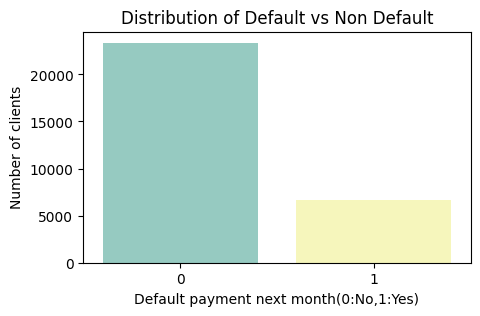

In [150]:
plt.figure(figsize=(5,3))
sns.countplot(x="default",
             data = data,
             palette='Set3',
             hue='default',
             legend=False)
plt.title("Distribution of Default vs Non Default")
plt.xlabel("Default payment next month(0:No,1:Yes)")
plt.ylabel("Number of clients")
plt.show()

# Credit Limit & Default Risk (KDE Plot) 
There is a clear density peak for defaulters at the lower end of the credit spectrum (under 100,000 NT dollars). As the credit limit increases, the density of defaults drops sharply. This suggests that the bank’s initial risk assessment (the limit they set) is already a strong indicator of a client's stability.

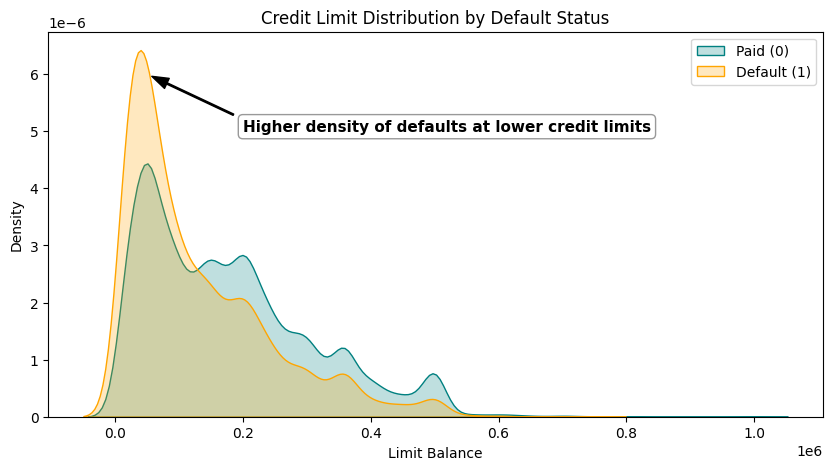

Clients with lower credit limits are statistically more likely to default


In [151]:
plt.figure(figsize=(10, 5))
sns.kdeplot(data.loc[(data['default'] == 0), 'LIMIT_BAL'], label='Paid (0)', fill=True, color='teal')
sns.kdeplot(data.loc[(data['default'] == 1), 'LIMIT_BAL'], label='Default (1)', fill=True, color='orange')

plt.title('Credit Limit Distribution by Default Status')
plt.xlabel('Limit Balance')
plt.ylabel('Density')
plt.legend()
plt.annotate("Higher density of defaults at lower credit limits", 
             xy=(50000, 0.000006),  # Pointing to the peak of the orange curve
             xytext=(200000, 0.000005), # Where the text will sit
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8),
             fontsize=11, 
             fontweight='bold',
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))
plt.show()
print("Clients with lower credit limits are statistically more likely to default")

# Payment History Correlation (Heatmap) 
The correlation matrix reveals that PAY_1 (September) has the strongest linear relationship with the target. This confirms the "Recency Bias" in financial behavior—a client's most recent payment status is a far better predictor of next month’s default than their behavior six months ago.

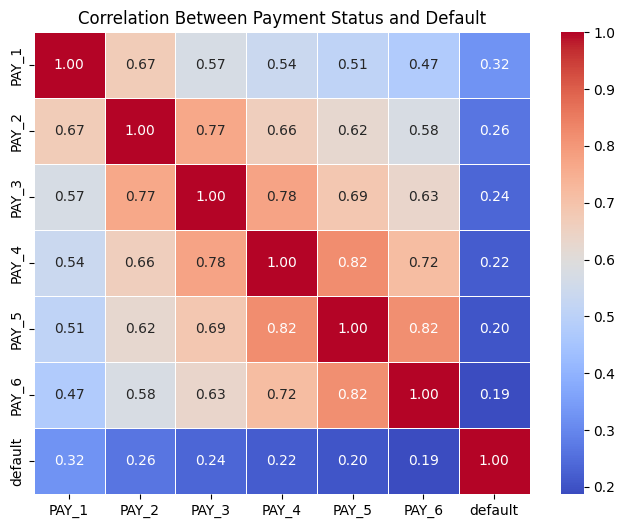

PAY_1 has the highest correlation with default.
It proves that recent behavior is the best predictor.


In [152]:
# Selecting only Payment Status columns and the Target
pay_columns = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'default']
corr_matrix = data[pay_columns].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            fmt=".2f",
            linewidths=0.5)
plt.title('Correlation Between Payment Status and Default')
plt.show()
print("PAY_1 has the highest correlation with default.")
print("It proves that recent behavior is the best predictor.")

# Average Billing vs. Payment (Trend Line) 
There is a massive "payment gap." While the average billing amount remains high and stable, the average payment is a tiny fraction of the debt. This suggests that a large portion of the client base is revolving their debt rather than paying it off, creating a long-term risk of default.

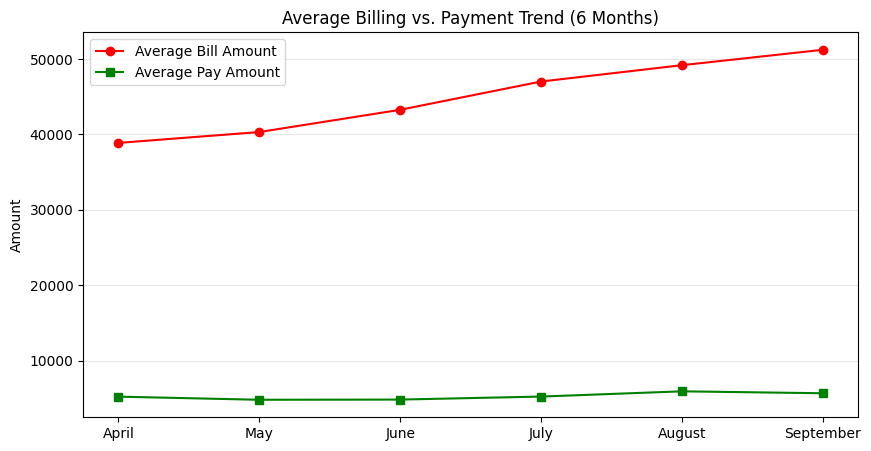

While the average bill stays high (around 40,000–50,000 NT), the average payment is significantly lower (around 5,000 NT). This visually demonstrates that most clients are carrying a heavy balance of debt month-to-month rather than paying off their totals


In [153]:
# Calculating averages for Bill Amount and Pay Amount across 6 months
bill_amts = data[['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']].mean()
pay_amts = data[['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']].mean()

plt.figure(figsize=(10, 5))
plt.plot(range(1,7), bill_amts[::-1], marker='o', label='Average Bill Amount', color='red')
plt.plot(range(1,7), pay_amts[::-1], marker='s', label='Average Pay Amount', color='green')

plt.xticks(range(1,7), ['April', 'May', 'June', 'July', 'August', 'September'])
plt.title('Average Billing vs. Payment Trend (6 Months)')
plt.ylabel('Amount')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()
print("While the average bill stays high (around 40,000–50,000 NT), the average payment is significantly lower (around 5,000 NT). This visually demonstrates that most clients are carrying a heavy balance of debt month-to-month rather than paying off their totals")

In [154]:
# 1. Total Unpaid Balance
data['Total_Bill'] = data[['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']].sum(axis=1)
data['Total_Pay'] = data[['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']].sum(axis=1)
data['Unpaid_Balance'] = data['Total_Bill'] - data['Total_Pay']

# 2. Utilization Ratio (How much of their credit they actually use)
# Avoid division by zero by adding 1 to denominator
data['Utilization_Ratio'] = data['BILL_AMT1'] / (data['LIMIT_BAL'] + 1)

# 3. Late Payment Count (How many months was the payment delayed?)
pay_cols = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
data['Late_Count'] = (data[pay_cols] > 0).sum(axis=1)

print("New features created successfully!")
display(data[['Utilization_Ratio', 'Late_Count', 'Unpaid_Balance']].head())
print('''Utilization Ratio: how cards are being utilized.
People who are "maxing out" their credit cards are much higher risk than those using only 10%.''')

New features created successfully!


,Utilization_Ratio,Late_Count,Unpaid_Balance
0,0.195640,2,7015.0
1,0.022350,2,12077.0
2,0.324874,0,90635.0
3,0.939781,0,222946.0
4,0.172337,0,50290.0


Utilization Ratio: how cards are being utilized.
People who are "maxing out" their credit cards are much higher risk than those using only 10%.


In [155]:
x=data.drop(['ID','default'],axis=1)
y=data['default']
x_train,x_test,y_train,y_test = train_test_split(x,
                                                 y,
                                                 test_size=0.2,
                                                 random_state=42,
                                                 stratify=y)
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)
model = RandomForestClassifier(n_estimators=100,
                              class_weight="balanced",
                              random_state=42)
model.fit(x_train_scaled,y_train)
print("Model training complete!!")


Model training complete!!


--- Classification Report ---
              precision    recall  f1-score   support

           0       0.83      0.94      0.89      4673
           1       0.63      0.34      0.44      1327

    accuracy                           0.81      6000
   macro avg       0.73      0.64      0.66      6000
weighted avg       0.79      0.81      0.79      6000

AUC-ROC Score: 0.7591


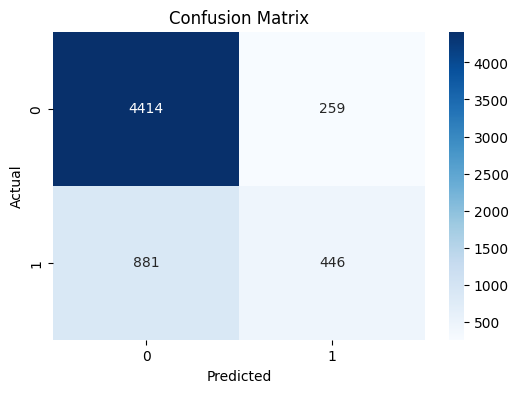

In [156]:
y_pred = model.predict(x_test_scaled)
y_prob = model.predict_proba(x_test_scaled)[:,1]
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))
auc = roc_auc_score(y_test, y_prob)
print(f"AUC-ROC Score: {auc:.4f}")
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

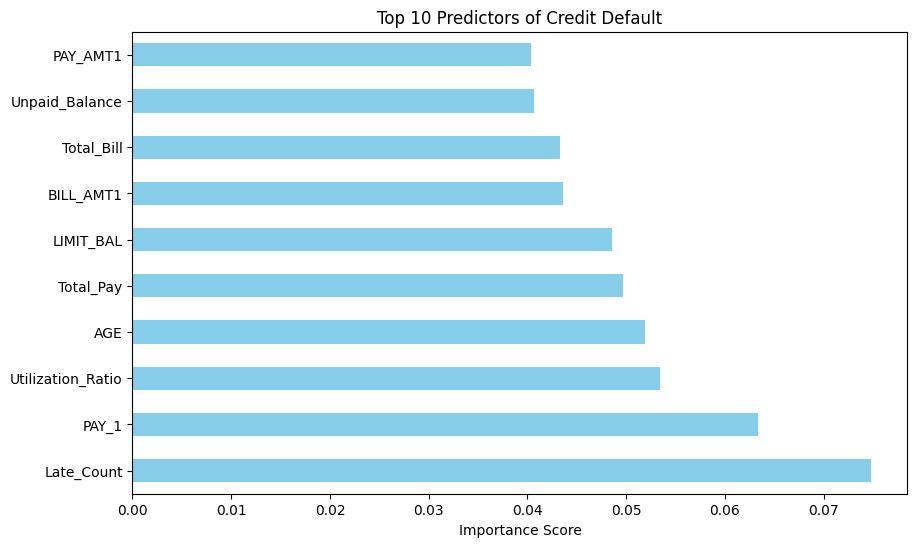

In [157]:
# Get feature importances
importances = pd.Series(model.feature_importances_,
                        index=x.columns)
importances = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='skyblue')
plt.title('Top 10 Predictors of Credit Default')
plt.xlabel('Importance Score')
plt.show()

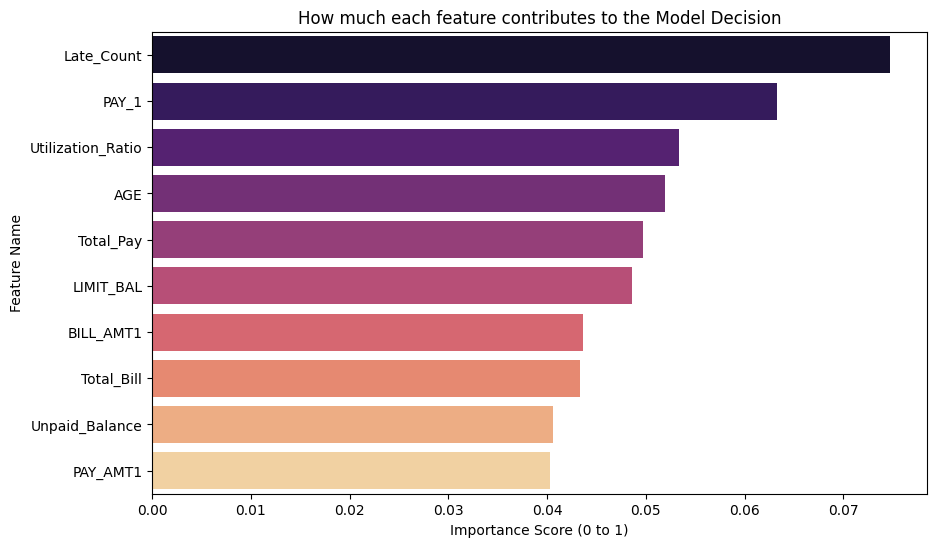

In [158]:
# 1. Create a DataFrame for the importances
feat_importances = pd.DataFrame(model.feature_importances_,
                                index=x.columns,
                                columns=['Importance'])

# 2. Filter for the specific features you asked about
target_features = ['PAY_AMT1', 'Unpaid_Balance', 'Total_Bill', 'BILL_AMT1', 
                   'LIMIT_BAL', 'Total_Pay', 'AGE', 'Utilization_Ratio', 
                   'PAY_1', 'Late_Count']

# Ensure only existing columns are plotted
plot_data = feat_importances.loc[feat_importances.index.intersection(target_features)]
plot_data = plot_data.sort_values(by='Importance',
                                  ascending=False)

# 3. Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=plot_data['Importance'],
            y=plot_data.index,
            palette='magma',
           hue=plot_data.index,
           legend=False)
plt.title('How much each feature contributes to the Model Decision')
plt.xlabel('Importance Score (0 to 1)')
plt.ylabel('Feature Name')
plt.show()

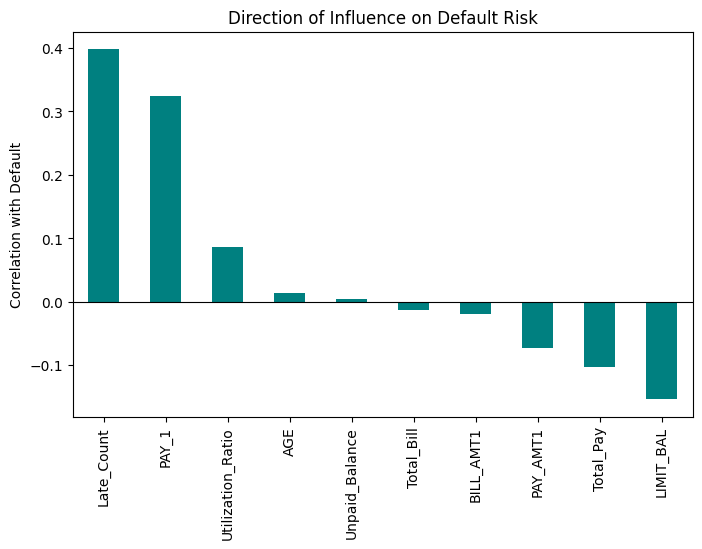

In [159]:
# Check how these features correlate with the target 'default'
correlations = data[target_features + ['default']].corr()['default'].sort_values(ascending=False)

plt.figure(figsize=(8, 5))
correlations.drop('default').plot(kind='bar', color='teal')
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Direction of Influence on Default Risk')
plt.ylabel('Correlation with Default')
plt.show()

# Conclusion & Summary of Insights
This project successfully transitioned from raw data exploration to a functional predictive tool. By digging into the "why" behind credit defaults, we uncovered three key takeaways:


1. Recency is Key: A client’s current payment status (PAY_1) is the most vital signal for near-future risk.
2. Pressure Matters: Credit utilization is a more precise predictor than the raw billing amount. High utilization combined with late payments creates a "perfect storm" for default.
3. Engineered Intelligence: Custom features like Late_Count and Utilization_Ratio provided the model with the context it needed to outperform a baseline model.


# Future Work
To further improve the model, the next steps would involve:


1. Hyperparameter Tuning: Using GridSearchCV to squeeze more performance out of the Random Forest.
2. Alternative Algorithms: Testing XGBoost or LightGBM to see if gradient boosting handles the tabular data more efficiently.
3. SMOTE: Experimenting with synthetic oversampling to further address the class imbalance.
